In [11]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold

df = pd.read_csv('feature_engineered.csv')

X = df[['Density', 'DrivAge', 'Exposure', 'VehAge','VehPower', 'BonusMalus', 'VehGas', 'exposure*bonusmalus', 'Density_over_VehAge', 'VehBrand']]
X = pd.get_dummies(X, drop_first=True, dtype=int)
y = df['ClaimNb']

kf = KFold(n_splits=5, shuffle=True, random_state=42)
X = X.to_numpy()
y = y.to_numpy()

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model = RandomForestRegressor(n_estimators=100, min_samples_leaf=12, max_depth=11, random_state=42)
    model.fit(X_train, y_train)

    y_hat = model.predict(X_test)

    print(f'R2 score: {r2_score(y_test, y_hat)}')


R2 score: 0.035672585401159695
R2 score: 0.039096787538069444
R2 score: 0.04273811235570468
R2 score: 0.03853703323153568
R2 score: 0.03746094422627855



 BEST HYPERPARAMETERS FOUND
max_depth = 11
min_leaves = 12
CV R²  = 0.03239


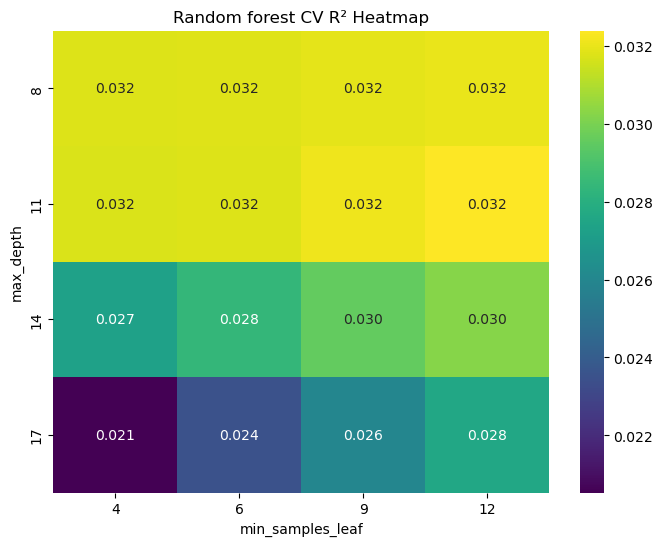

In [6]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('feature_engineered.csv')

X = df[['Density', 'DrivAge', 'Exposure', 'VehAge','VehPower', 'BonusMalus', 'VehGas']]
X = pd.get_dummies(X, drop_first=True)
y = df['ClaimNb']

X = X.to_numpy()
y = y.to_numpy()

kf = KFold(n_splits=3, shuffle=True, random_state=42)

# hyperparameters
max_depth_values = [8, 11, 14, 17]
min_leaf_values = [4,6,9, 12]
results = []

# heatmap for plotting
r2_matrix = np.zeros((len(max_depth_values), len(min_leaf_values)))

# cross validation for each hyperparameter combination
for i, d in enumerate(max_depth_values):
    for j, l in enumerate(min_leaf_values):
        r2_scores = []

        for train_index, test_index in kf.split(X):
            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]

            model = RandomForestRegressor(n_estimators=50,random_state=42, max_depth=d, min_samples_leaf=l, n_jobs=-1)
            model.fit(X_train, y_train)
            y_hat = model.predict(X_test)

            r2_scores.append(r2_score(y_test, y_hat))

        avg_r2 = np.mean(r2_scores)
        results.append(((d, l), avg_r2))
        r2_matrix[i, j] = avg_r2

# getting the best result from stored R2 values
best_config = max(results, key=lambda x: x[1])
(best_d, best_l), best_r2 = best_config
print(f"max_depth = {best_d}")
print(f"min_leaves = {best_l}")
print(f"CV R2  = {best_r2:.5f}")
plt.figure(figsize=(8, 6))
sns.heatmap(r2_matrix, annot=True, fmt=".3f",
            xticklabels=min_leaf_values,
            yticklabels=max_depth_values,
            cmap="viridis")
plt.xlabel("min_samples_leaf")
plt.ylabel("max_depth")
plt.title("Random forest CV R2 Heatmap")
plt.show()


In [9]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split


df = pd.read_csv('feature_engineered.csv')

X = df[['Density', 'DrivAge', 'Exposure', 'VehAge','VehPower', 'BonusMalus', 'VehGas', 'exposure*bonusmalus', 'Density_over_VehAge', 'VehBrand']]
X = pd.get_dummies(X, drop_first=True, dtype=int)
y = df['ClaimNb']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=.25, random_state=42)

model = RandomForestRegressor(n_estimators=300, min_samples_leaf=12, max_depth=11, random_state=42)
model.fit(x_train, y_train)

y_hat = model.predict(x_test)

print(f'R2 score: {r2_score(y_test, y_hat)}')

claims_df = pd.DataFrame(data={'claims_true': y_test, 'claims_predicted': y_hat})
claims_df.to_csv('RF_predictions.csv')

R2 score: 0.03687707637248727


In [3]:
dataframe = pd.read_csv('RF_predictions.csv')
dataframe

,Unnamed: 0,claims_true,claims_predicted
0,388582,0,0.025197
1,147210,0,0.012610
2,310703,0,0.063506
3,450637,1,0.068741
4,495721,0,0.102856
...,...,...,...
135598,487660,0,0.040631
135599,120812,0,0.038546
135600,241137,0,0.055997
135601,461350,1,0.074633


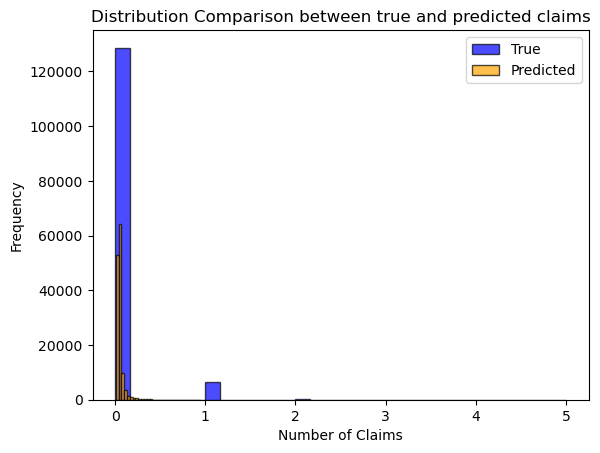

In [23]:
import matplotlib.pyplot as plt
import numpy as np

y_true = dataframe['claims_true']
y_pred = dataframe['claims_predicted']

plt.hist(y_true, bins=30, alpha=0.7, label='True', color='blue', edgecolor='black')
plt.hist(y_pred, bins=30, alpha=0.7, label='Predicted', color='orange', edgecolor='black')
plt.xlabel('Number of Claims')
plt.ylabel('Frequency')
plt.title('Distribution Comparison between true and predicted claims')
plt.legend()

Check the same configurations of hyperparameters as we used for M1 decision tree for overfitting.

In [8]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv('feature_engineered.csv')

# --------------------------
# Features / Target
# --------------------------
X = df[['Density', 'DrivAge', 'Exposure', 'VehAge', 'VehPower',
        'BonusMalus', 'VehGas', 'exposure*bonusmalus',
        'Density_over_VehAge', 'VehBrand']]

X = pd.get_dummies(X, drop_first=True)
y = df['ClaimNb']

# --------------------------
# Train / Validation only
# --------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# --------------------------
# Train model
# --------------------------
clf = RandomForestRegressor(n_estimators=100, random_state=42, min_samples_leaf=12, max_depth=11)
clf.fit(X_train, y_train)

# --------------------------
# Evaluate
# --------------------------
y_pred_train = clf.predict(X_train)
y_pred_val = clf.predict(X_val)

print("--------------- TRAIN SET ---------------")
print("MSE:", mean_squared_error(y_train, y_pred_train))
print(f"R² Score: {r2_score(y_train, y_pred_train):.4f}")

print("\n--------------- VALIDATION SET ---------------")
print("MSE:", mean_squared_error(y_val, y_pred_val))
print(f"R² Score: {r2_score(y_val, y_pred_val):.4f}")


--------------- TRAIN SET ---------------
MSE: 0.052708127385116425
R² Score: 0.0755

--------------- VALIDATION SET ---------------
MSE: 0.055030417388590984
R² Score: 0.0365


In [4]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
df = pd.read_csv('feature_engineered.csv')

X = df[['Density', 'DrivAge', 'Exposure', 'VehAge','VehPower', 'BonusMalus', 'VehGas', 'exposure*bonusmalus', 'Density_over_VehAge', 'VehBrand']]
X = pd.get_dummies(X, drop_first=True, dtype=int)
y = df['ClaimNb']
numeric_cols = [
    'Density', 'DrivAge', 'Exposure', 'VehAge',
    'VehPower', 'BonusMalus',
    'exposure*bonusmalus', 'Density_over_VehAge'
]

scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])